In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import datetime as datetime

In [5]:
df = pd.read_csv("Nat_Gas.csv")
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [9]:
df.info

<bound method DataFrame.info of        Dates  Prices
0   10/31/20   10.10
1   11/30/20   10.30
2   12/31/20   11.00
3    1/31/21   10.90
4    2/28/21   10.90
5    3/31/21   10.90
6    4/30/21   10.40
7    5/31/21    9.84
8    6/30/21   10.00
9    7/31/21   10.10
10   8/31/21   10.30
11   9/30/21   10.20
12  10/31/21   10.10
13  11/30/21   11.20
14  12/31/21   11.40
15   1/31/22   11.50
16   2/28/22   11.80
17   3/31/22   11.50
18   4/30/22   10.70
19   5/31/22   10.70
20   6/30/22   10.40
21   7/31/22   10.50
22   8/31/22   10.40
23   9/30/22   10.80
24  10/31/22   11.00
25  11/30/22   11.60
26  12/31/22   11.60
27   1/31/23   12.10
28   2/28/23   11.70
29   3/31/23   12.00
30   4/30/23   11.50
31   5/31/23   11.20
32   6/30/23   10.90
33   7/31/23   11.40
34   8/31/23   11.10
35   9/30/23   11.50
36  10/31/23   11.80
37  11/30/23   12.20
38  12/31/23   12.80
39   1/31/24   12.60
40   2/29/24   12.40
41   3/31/24   12.70
42   4/30/24   12.10
43   5/31/24   11.40
44   6/30/24   11.50
45

In [13]:
df['Dates'] = pd.to_datetime(df['Dates'])

In [15]:
df  =df.sort_values('Dates').reset_index(drop = True)

In [16]:
df.head()

,Dates,Prices
0,2020-10-31,10.1
1,2020-11-30,10.3
2,2020-12-31,11.0
3,2021-01-31,10.9
4,2021-02-28,10.9


In [18]:
print("data types and non null counts:")
print(df.info())

data types and non null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes
None


In [20]:
print("\n summary statistics:")
print(df.describe())


 summary statistics:
                     Dates     Prices
count                   48  48.000000
mean   2022-10-15 08:00:00  11.207083
min    2020-10-31 00:00:00   9.840000
25%    2021-10-23 06:00:00  10.650000
50%    2022-10-15 12:00:00  11.300000
75%    2023-10-07 18:00:00  11.625000
max    2024-09-30 00:00:00  12.800000
std                    NaN   0.757897


In [26]:
def interpolate_past(df, input_date):
    target_dt = pd.to_datetime(input_date)
    #convert date to integer so that numpy interpolate numerically
    timestamps = df['Dates'].astype('int64') // 10**9
    target_timestamp = target_dt.value // 10**9
    # np.interp(target_x, known_x_array, known_y_array)
    price = np.interp(target_timestamp, timestamps, df['Prices'])
    return round(float(price), 2)

In [27]:
print('price on oct 2 2022:', interpolate_past(df, "2022-10-2")) #trial

price on oct 2 2022: 10.81


In [28]:
#future price prediction
# Convert dates to number of days elapsed from the start date
start_date = df['Dates'].min()
df['Days'] = (df['Dates'] - start_date).dt.days

# Fit a baseline linear trend (y = m*x + c)
slope, intercept = np.polyfit(df['Days'], df['Prices'], 1)

# Calculate trend prices and isolate the seasonal residuals (Price - Trend)
df['Trend'] = slope * df['Days'] + intercept
df['Residual'] = df['Prices'] - df['Trend']
df['Month'] = df['Dates'].dt.month

#Compute the average seasonal offset for each month (1 = Jan, 12 = Dec)
seasonal_offsets = df.groupby('Month')['Residual'].mean().to_dict()

In [30]:
def estimate_price(input_date_str):
    target_date = pd.to_datetime(input_date_str)
    min_date = df['Dates'].min()
    max_date = df['Dates'].max()
    max_future_date = max_date + pd.DateOffset(years=1)
    
    if min_date <= target_date <= max_date:
        timestamps = df['Dates'].astype('int64') // 10**9
        target_timestamp = target_date.value // 10**9
        interpolated_price = np.interp(target_timestamp, timestamps, df['Prices'])
        return round(float(interpolated_price), 2)
    
    elif max_date < target_date <= max_future_date:
        days_elapsed = (target_date - start_date).days
        baseline_trend = slope * days_elapsed + intercept
        
        month = target_date.month
        seasonal_factor = seasonal_offsets.get(month, 0)
        
        extrapolated_price = baseline_trend + seasonal_factor
        return round(float(extrapolated_price), 2)
    else:
        raise ValueError(
            f"Date out of supported range! Please provide a date between "
            f"{min_date.strftime('%Y-%m-%d')} and {max_future_date.strftime('%Y-%m-%d')}."
        )

In [31]:
print("Past Price on Nov 15, 2022:", estimate_price("2022-11-15"))
print("Future Price on Jan 15, 2025:", estimate_price("2025-01-15"))
print("Future Price on Jul 15, 2025:", estimate_price("2025-07-15"))

Past Price on Nov 15, 2022: 11.3
Future Price on Jan 15, 2025: 12.93
Future Price on Jul 15, 2025: 12.05


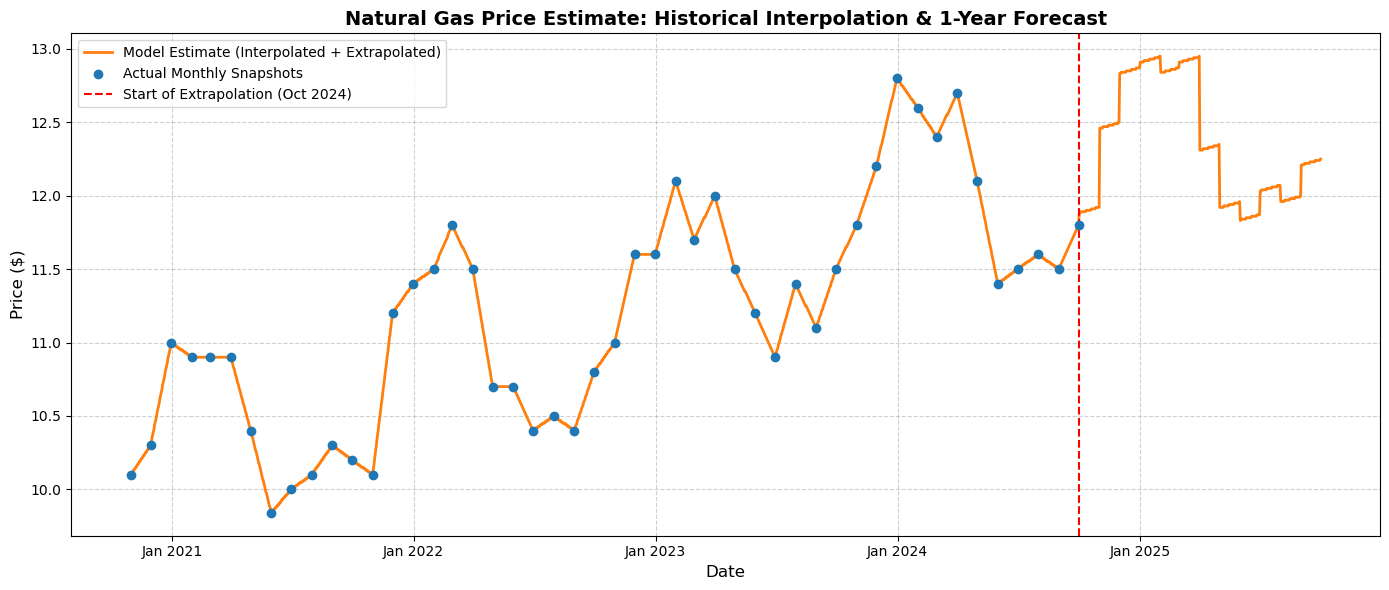

In [32]:
#plot the data
future_end = df['Dates'].max() + pd.DateOffset(years=1)
daily_dates = pd.date_range(start=df['Dates'].min(), end=future_end, freq='D')
daily_prices = [estimate_price(d.strftime('%Y-%m-%d')) for d in daily_dates]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(daily_dates, daily_prices, label='Model Estimate (Interpolated + Extrapolated)', color='#ff7f0e', linewidth=2)
plt.scatter(df['Dates'], df['Prices'], color='#1f77b4', zorder=5, label='Actual Monthly Snapshots')

plt.axvline(x=df['Dates'].max(), color='red', linestyle='--', label='Start of Extrapolation (Oct 2024)')

plt.title('Natural Gas Price Estimate: Historical Interpolation & 1-Year Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()